Notebook illustrating the IF-DTW mining strategy of the paper. 

We only consider data from ILL11 for 2018. Note that you need to run the if_illustration.ipynb notebook first.

Data can be downloaded from: https://doi.org/10.12686/SED/NETWORKS/XP

In [1]:
import obspy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import load
from seismicif.datamod.loading_utils import preproc_flow_annotations, extract_template
from seismicif.dtw import template_dtw
from seismicif.metrics import iou, est_thresholds, compute_statistics

First we extract templates from the high-confidence segments

In [2]:
folder = "../data/XP/2018/ILL11/HHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

if_mod = load("../output/if_models/ILL11_illustration.joblib")

flows = preproc_flow_annotations(pd.read_csv("../catalogues/flow_catalogue.csv"))
flows = flows[flows["station"] == "ILL11"].reset_index(drop=True)
flows = flows[flows["stop"] < obspy.UTCDateTime("2018-12-31T23:59:59")].reset_index(
    drop=True
)

high_conf_flows = flows[flows["confidence"] == 1.0].reset_index(drop=True)
lower_conf_flows = flows[flows["confidence"] != 1.0].reset_index(drop=True)

In [3]:
templates = []
for i in range(high_conf_flows.shape[0]):
    t0 = high_conf_flows["start"][i]
    t1 = high_conf_flows["stop"][i]
    templates.append(extract_template(t0, t1, if_mod, stream_paths))
templates = np.array(templates)

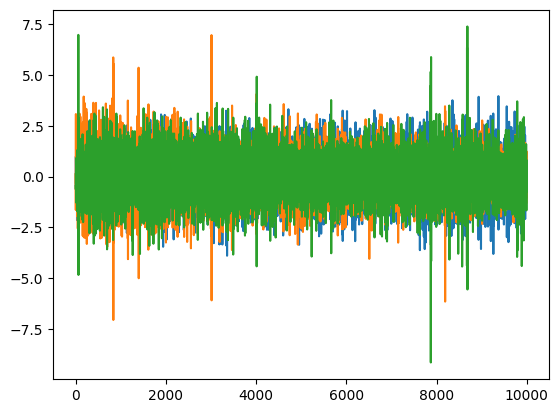

In [4]:
for tem in templates:
    plt.plot(tem)

When performing DTW we only consider segments flagged by the IF trigger. The code may take a few minutes to run.

In [5]:
if_segments = preproc_flow_annotations(
    pd.read_csv("../output/if_segments/ILL11_illustration.csv", index_col=0)
)

In [13]:
try:
    dtw_dists = np.load("../output/dtw_distances/ILL11_illustration.npy")

except (FileNotFoundError, OSError):
    dtw_dists = []
    for i in range(if_segments.shape[0]):
        dtw_dists.append(
            template_dtw(
                if_segments["start"][i],
                if_segments["stop"][i],
                stream_paths,
                templates,
                if_mod,
            )
        )
    dtw_dists = np.array(dtw_dists)

    np.save("../output/dtw_distances/ILL11_illustration.npy", dtw_dists)

For each segment flagged by the IF trigger we compute the mean of the DTW distances w.r.t the templates. However, if a flagged segment overlaps with a high-confidence segment the DTW distance w.r.t the corresponding template is excluded.

In [14]:
dtw_scores = []

for i in range(dtw_dists.shape[0]):
    intersection, _, _ = iou(
        high_conf_flows, if_segments.loc[[i]].reset_index(drop=True)
    )
    high_conf_overlap = np.append(intersection[0], np.diff(intersection)) > 0

    dtw_scores.append(np.mean(dtw_dists[i, ~high_conf_overlap]))

dtw_segments = if_segments.copy()
dtw_segments["scores"] = dtw_scores
dtw_segments = dtw_segments.iloc[np.argsort(dtw_segments["scores"])].reset_index(
    drop=True
)

To obtain the final detections we calibrate a minimum length and score threshold.

As in the case of IF, we deal with lower confidence segments by keeping all segments that either overlap with a high-confidence segment or that do not overlap with any lower-confidence segments.

In [15]:
intersections, _, _ = iou(dtw_segments, lower_conf_flows)
non_lower_conf = np.append(intersections[0], np.diff(intersections)) == 0
intersections, _, _ = iou(dtw_segments, high_conf_flows)
high_conf = np.append(intersections[0], np.diff(intersections)) > 0
valid_detections = dtw_segments[non_lower_conf | high_conf].reset_index(drop=True)

In [16]:
_, min_len, score_thres = est_thresholds(
    valid_detections, high_conf_flows, mode="upper"
)
print(min_len, score_thres)

100.0 9496.270028285564


In [17]:
dtw_detections = valid_detections.copy()

start_times = np.array([pd.to_datetime(str(i)) for i in dtw_detections["start"]])
end_times = np.array([pd.to_datetime(str(i)) for i in dtw_detections["stop"]])

det_lens = np.array([i.total_seconds() for i in end_times - start_times])
dtw_detections = dtw_detections.assign(det_lens=det_lens)
dtw_detections = dtw_detections[
    (dtw_detections["scores"] < score_thres) & (dtw_detections["det_lens"] > min_len)
].reset_index(drop=True)

dtw_detections

,start,stop,scores,det_lens
0,2018-06-12T19:10:45.690000Z,2018-06-12T19:52:25.690000Z,7437.631664,2500.0
1,2018-06-12T19:55:45.690000Z,2018-06-12T19:58:15.690000Z,7478.246580,150.0
2,2018-06-12T19:52:25.690000Z,2018-06-12T19:55:45.690000Z,7786.796073,200.0
3,2018-08-08T17:55:45.690000Z,2018-08-08T18:50:45.690000Z,7846.702177,3300.0
4,2018-07-25T17:04:05.690000Z,2018-07-25T18:02:25.690000Z,7979.043900,3500.0


Printout of final statistics. Note that the IOU is a bit higher than for the IF mining method...this is due to the inclusion of 2 shorter detections that overlap with the high-confidence segment of 2018-06-12.

In [18]:
compute_statistics(dtw_detections, high_conf_flows)

{'iou': 57.30470962653247,
 'recall': 100.0,
 'FN': 0,
 'precision': 100.0,
 'FP': 0,
 'TP': 3}

Generate all detections, including those that may overlap with lower-confidence segments.

In [19]:
all_dtw_detections = dtw_segments.copy()

start_times = np.array([pd.to_datetime(str(i)) for i in all_dtw_detections["start"]])
end_times = np.array([pd.to_datetime(str(i)) for i in all_dtw_detections["stop"]])

det_lens = np.array([i.total_seconds() for i in end_times - start_times])
all_dtw_detections = all_dtw_detections.assign(det_lens=det_lens)
all_dtw_detections = all_dtw_detections[
    (all_dtw_detections["scores"] < score_thres)
    & (all_dtw_detections["det_lens"] > min_len)
].reset_index(drop=True)

all_dtw_detections

,start,stop,scores,det_lens
0,2018-06-12T19:10:45.690000Z,2018-06-12T19:52:25.690000Z,7437.631664,2500.0
1,2018-06-12T19:55:45.690000Z,2018-06-12T19:58:15.690000Z,7478.246580,150.0
2,2018-06-11T12:06:35.690000Z,2018-06-11T12:14:05.690000Z,7662.950102,450.0
3,2018-06-12T19:52:25.690000Z,2018-06-12T19:55:45.690000Z,7786.796073,200.0
4,2018-08-08T17:55:45.690000Z,2018-08-08T18:50:45.690000Z,7846.702177,3300.0
5,2018-06-11T11:33:15.690000Z,2018-06-11T12:05:45.690000Z,7854.749068,1950.0
6,2018-07-25T17:04:05.690000Z,2018-07-25T18:02:25.690000Z,7979.043900,3500.0
